Hierarchical AR(1) with partial pooling and national covariates.

$$\mu_\alpha \sim \mathcal{N}(5, 3)$$
$$\sigma_\alpha \sim \text{Exp}(1/2)$$
$$\mu_\beta \sim \mathcal{N}(0.5, 0.3)$$
$$\sigma_\beta \sim \text{Exp}(1/0.3)$$
$$\gamma_{fed} \sim \mathcal{N}(0, 1)$$
$$\gamma_{gdp} \sim \mathcal{N}(0, 1)$$
$$\sigma \sim \text{Exp}(1)$$
$$\tilde{\alpha}_s \sim \mathcal{N}(0, 1), \quad \alpha_s = \mu_\alpha + \sigma_\alpha \tilde{\alpha}_s$$
$$\tilde{\beta}_s \sim \mathcal{N}(0, 1), \quad \beta_s = \mu_\beta + \sigma_\beta \tilde{\beta}_s$$
$$y_{s,t} \mid \alpha_s, \beta_s, \gamma, \sigma \sim \mathcal{N}\!\left(\alpha_s + \beta_s\, y_{s,t-1} + \gamma_{fed}\, \text{FEDFUNDS}_t + \gamma_{gdp}\, \text{GDP}_t,\ \sigma\right)$$

In [12]:
library(cmdstanr)
library(dplyr)
library(tidyr)
library(ggplot2)
set.seed(405)

dir.create("../results", showWarnings=FALSE)

TRAIN_END <- as.Date("2023-12-01")

## 1. Load and prepare data

In [13]:
bls <- read.csv("../cleaned_data/bls_data.csv") %>% mutate(date = as.Date(date))
fed <- read.csv("../cleaned_data/fedfunds_data.csv") %>% mutate(date = as.Date(date))
gdp <- read.csv("../cleaned_data/gdp_data.csv") %>% mutate(date = as.Date(date))

bls_cov <- bls %>% left_join(fed, by = "date") %>% left_join(gdp, by = "date")

bls_train <- bls_cov %>%
  filter(date <= TRAIN_END) %>%
  arrange(state, date) %>%
  group_by(state) %>%
  mutate(bls_lag = lag(unemployment_rate), state_id = cur_group_id()) %>%
  filter(!is.na(bls_lag)) %>%
  ungroup()

bls_test <- bls_cov %>%
  filter(date > TRAIN_END) %>%
  arrange(state, date) %>%
  group_by(state) %>%
  mutate(bls_lag = lag(unemployment_rate, default = NA)) %>%
  ungroup()

last_train <- bls_cov %>%
  filter(date == TRAIN_END) %>%
  arrange(state) %>%
  select(state, last_ur = unemployment_rate)

bls_test <- bls_test %>%
  group_by(state) %>%
  mutate(
    bls_lag = lag(unemployment_rate),
    bls_lag = if_else(is.na(bls_lag),
                      last_train$last_ur[match(state, last_train$state)],
                      bls_lag),
    state_id = cur_group_id()
  ) %>%
  ungroup()

states <- sort(unique(bls_train$state))
S  <- length(states)
N  <- nrow(bls_train)
N_test <- nrow(bls_test)


## 2. Compile and sample (HMC)

In [14]:
mod2 <- cmdstan_model("model2.stan")

stan_data <- list(
  N = N, 
  S = S,
  y = bls_train$unemployment_rate,
  y_lag = bls_train$bls_lag,
  state_id = bls_train$state_id,
  fed_rate = bls_train$fed_rate,
  gdp_growth = bls_train$gdp_growth,
  N_test = N_test,
  y_lag_test = bls_test$bls_lag,
  state_id_test = bls_test$state_id,
  fed_rate_test = bls_test$fed_rate,
  gdp_growth_test = bls_test$gdp_growth
)

fit2 <- mod2$sample(
  data = stan_data,
  seed = 405,
  chains = 4,
  parallel_chains = 4,
  iter_warmup = 1000,
  iter_sampling = 1000,
  refresh = 250
)

fit2$save_object("../results/model2_fit.rds")

Running MCMC with 4 parallel chains...

Chain 1 Iteration:    1 / 2000 [  0%]  (Warmup) 
Chain 2 Iteration:    1 / 2000 [  0%]  (Warmup) 
Chain 3 Iteration:    1 / 2000 [  0%]  (Warmup) 
Chain 4 Iteration:    1 / 2000 [  0%]  (Warmup) 
Chain 4 Iteration:  250 / 2000 [ 12%]  (Warmup) 
Chain 1 Iteration:  250 / 2000 [ 12%]  (Warmup) 
Chain 2 Iteration:  250 / 2000 [ 12%]  (Warmup) 
Chain 3 Iteration:  250 / 2000 [ 12%]  (Warmup) 
Chain 4 Iteration:  500 / 2000 [ 25%]  (Warmup) 
Chain 1 Iteration:  500 / 2000 [ 25%]  (Warmup) 
Chain 2 Iteration:  500 / 2000 [ 25%]  (Warmup) 
Chain 4 Iteration:  750 / 2000 [ 37%]  (Warmup) 
Chain 3 Iteration:  500 / 2000 [ 25%]  (Warmup) 
Chain 1 Iteration:  750 / 2000 [ 37%]  (Warmup) 
Chain 2 Iteration:  750 / 2000 [ 37%]  (Warmup) 
Chain 4 Iteration: 1000 / 2000 [ 50%]  (Warmup) 
Chain 4 Iteration: 1001 / 2000 [ 50%]  (Sampling) 
Chain 3 Iteration:  750 / 2000 [ 37%]  (Warmup) 
Chain 1 Iteration: 1000 / 2000 [ 50%]  (Warmup) 
Chain 1 Iteration: 1001 / 2

## 3. Diagnostics

In [15]:
diag <- fit2$summary(c("mu_alpha", "sigma_alpha", "mu_beta", "sigma_beta", "gamma_fed", "gamma_gdp", "sigma", "alpha", "beta")) %>%
  select(variable, mean, sd, q5, q95, rhat, ess_bulk, ess_tail)

print(paste("R-hat range: ", paste(round(range(diag$rhat), 4), collapse = " - ")))
print(paste("Bulk ESS range: ", paste(round(range(diag$ess_bulk)), collapse = " - ")))
print(paste("Tail ESS range: ", paste(round(range(diag$ess_tail)), collapse = " - ")))

diag %>% filter(variable %in% c("mu_alpha", "sigma_alpha", "mu_beta",
                                 "sigma_beta", "gamma_fed", "gamma_gdp", "sigma"))

[1] "R-hat range:  0.9994 - 1.021"
[1] "Bulk ESS range:  620 - 7669"
[1] "Tail ESS range:  883 - 3506"


variable,mean,sd,q5,q95,rhat,ess_bulk,ess_tail
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
mu_alpha,0.258009742,0.0102037822,0.241355268,0.274712134,1.0008404,4399.5364,2769.0541
sigma_alpha,0.022694953,0.0089979733,0.007299462,0.037616153,1.0210108,620.4509,883.1768
mu_beta,0.965571652,0.0018270598,0.962507014,0.968579918,1.0009817,3442.7924,3428.6309
sigma_beta,0.006088790,0.0012292220,0.004287192,0.008240140,1.0020080,1338.0364,2274.1604
gamma_fed,0.006171828,0.0006916722,0.005044460,0.007316157,0.9999047,3825.4369,2843.1080
gamma_gdp,-0.034444095,0.0006325632,-0.035483326,-0.033399200,0.9998990,4272.0277,2350.1679
sigma,0.466304163,0.0019704484,0.463136259,0.469581409,0.9998178,7668.5048,2917.1064


## 4. Trace plots — hyperparameters

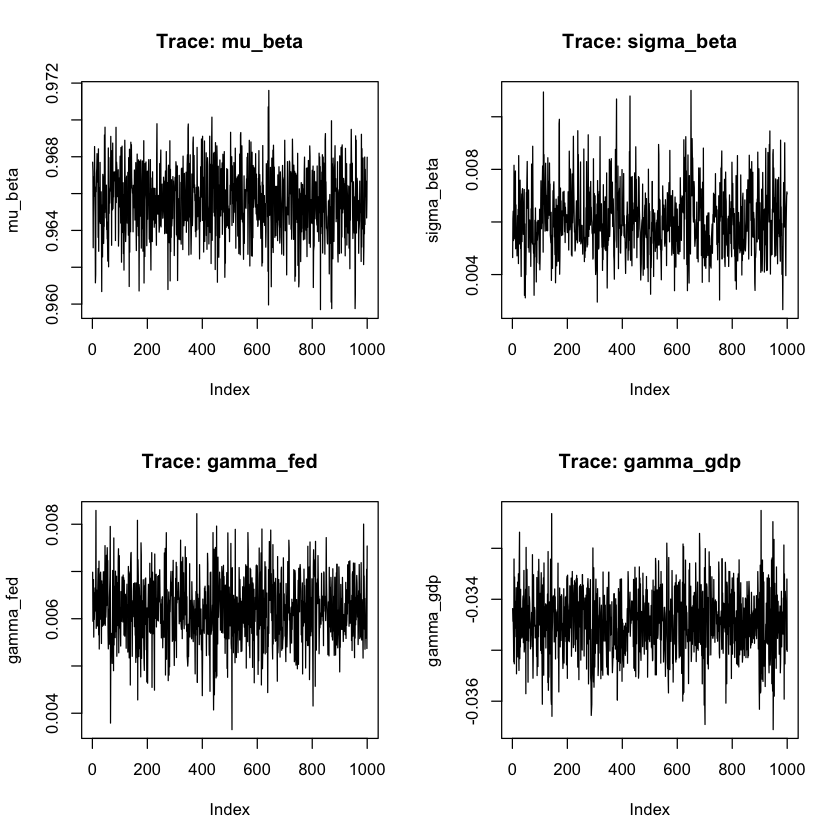

In [16]:
draws <- fit2$draws(format = "df")

par(mfrow = c(2, 2))
plot(draws$mu_beta[draws$.chain    == 1], type = "l", main = "Trace: mu_beta",    ylab = "mu_beta")
plot(draws$sigma_beta[draws$.chain == 1], type = "l", main = "Trace: sigma_beta", ylab = "sigma_beta")
plot(draws$gamma_fed[draws$.chain  == 1], type = "l", main = "Trace: gamma_fed",  ylab = "gamma_fed")
plot(draws$gamma_gdp[draws$.chain  == 1], type = "l", main = "Trace: gamma_gdp",  ylab = "gamma_gdp")
par(mfrow = c(1, 1))

## 5. Posterior beta_s — all states

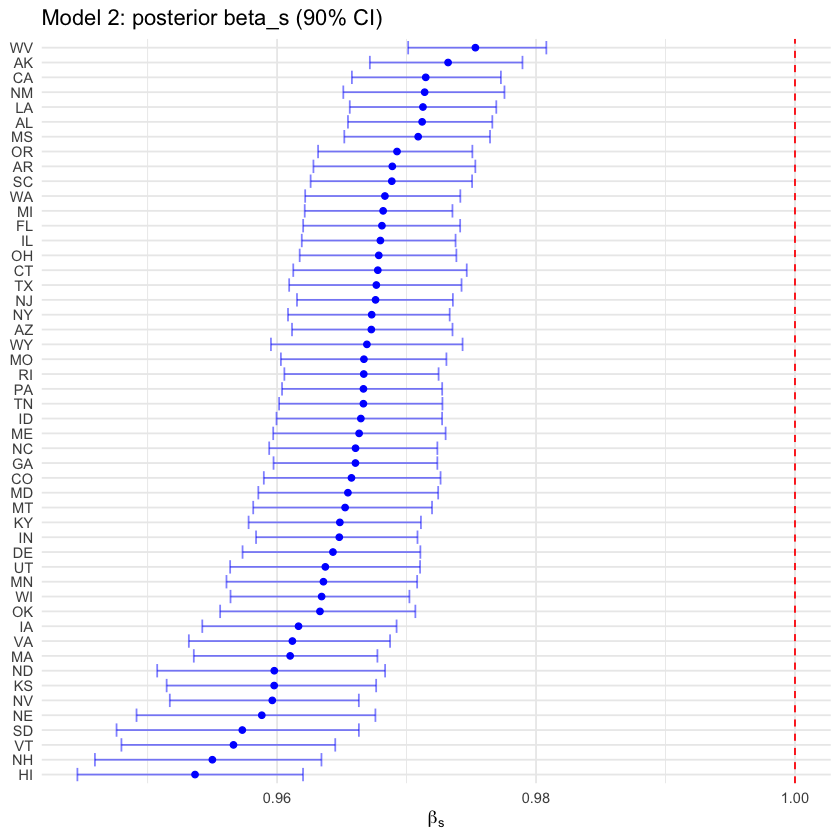

In [17]:
beta_summary2 <- fit2$summary("beta") %>%
  mutate(state = states)

p_beta2 <- ggplot(beta_summary2, aes(x = reorder(state, mean), y = mean)) +
  geom_point(colour = "blue") +
  geom_errorbar(aes(ymin = q5, ymax = q95), colour = "blue", alpha = 0.5) +
  geom_hline(yintercept = 1, linetype = "dashed", colour = "red") +
  labs(title = "Model 2: posterior beta_s (90% CI)", x = NULL, y = expression(beta[s])) +
  coord_flip() +
  theme_minimal()

p_beta2

## 6. Shrinkage plot — Model 1 vs Model 2 beta_s

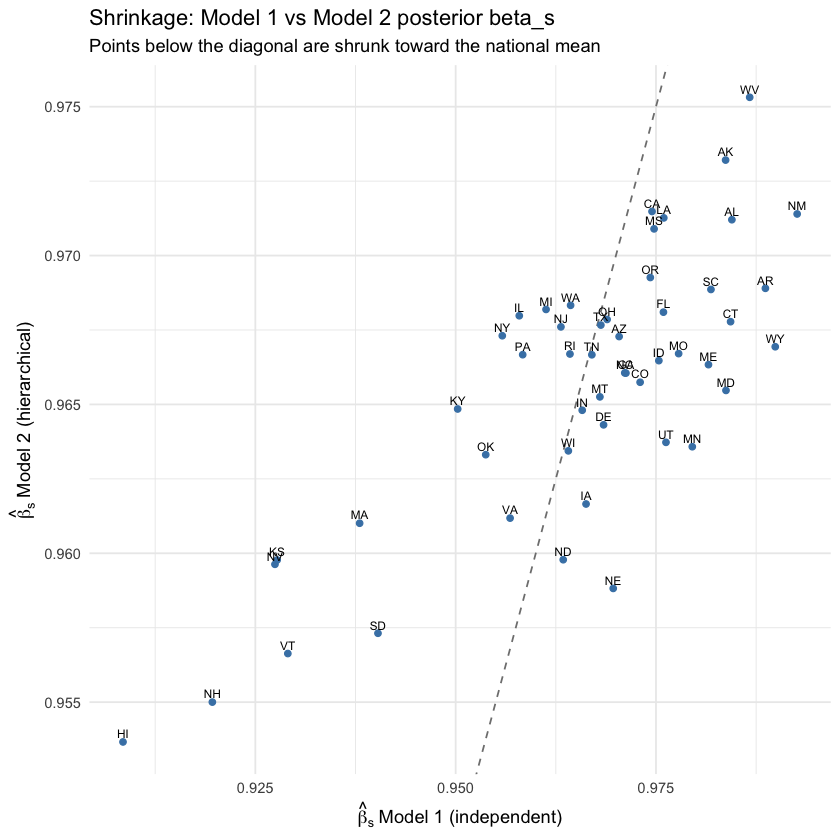

In [30]:
m1_results <- readRDS("../results/model1_results.rds")

shrinkage_df <- data.frame(
  state   = states,
  beta_m1 = m1_results$beta_hat,
  beta_m2 = fit2$summary("beta")$mean
)

p_shrink <- ggplot(shrinkage_df, aes(x = beta_m1, y = beta_m2, label = state)) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", colour = "grey50") +
  geom_point(colour = "steelblue") +
  geom_text(size = 2.5, vjust = -0.5) +
  labs(
    title    = "Shrinkage: Model 1 vs Model 2 posterior beta_s",
    subtitle = "Points below the diagonal are shrunk toward the national mean",
    x = expression(hat(beta)[s] ~ "Model 1 (independent)"),
    y = expression(hat(beta)[s] ~ "Model 2 (hierarchical)")
  ) +
  theme_minimal()

p_shrink

## 7. Posterior predictive check (PPC)

Saving 7 x 7 in image


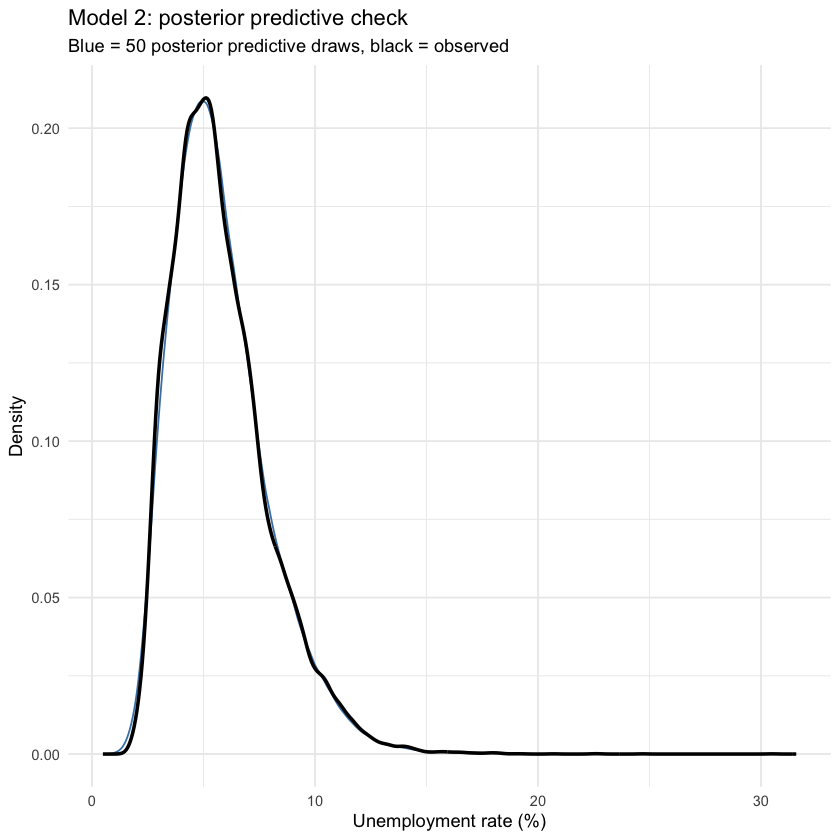

In [ ]:
y_rep_draws <- fit2$draws("y_rep", format = "matrix")
rep_idx <- sample(nrow(y_rep_draws), 50)

rep_df <- data.frame(
  value  = as.vector(y_rep_draws[rep_idx, ]),
  source = "y_rep"
)
obs_df <- data.frame(
  value  = bls_train$unemployment_rate,
  source = "observed"
)

p_ppc2 <- ggplot() +
  geom_density(data = rep_df, aes(x = value, group = source), colour = "steelblue", alpha = 0.15) +
  geom_density(data = obs_df, aes(x = value), colour = "black", linewidth = 1) +
  labs(title = "Model 2: posterior predictive check", subtitle = "Blue = 50 posterior predictive draws, black = observed", x = "Unemployment rate (%)", y = "Density") +
  theme_minimal()

p_ppc2

## 8. Test-set RMSE

In [31]:
alpha_hat2 <- fit2$summary("alpha")$mean
beta_hat2 <- fit2$summary("beta")$mean
gamma_fed_hat <- fit2$summary("gamma_fed")$mean
gamma_gdp_hat <- fit2$summary("gamma_gdp")$mean

bls_test <- bls_cov %>% filter(date > TRAIN_END) %>% arrange(state, date)
test_dates <- sort(unique(bls_test$date))

y_prev <- bls_cov %>%
  filter(date == TRAIN_END) %>%
  arrange(state) %>%
  pull(unemployment_rate)

forecast_list2 <- vector("list", length(test_dates))

for (i in seq_along(test_dates)) {
  d <- test_dates[i]
  covs <- bls_test %>% filter(date == d) %>% arrange(state)
  y_pred <- alpha_hat2 + beta_hat2 * y_prev + gamma_fed_hat * covs$fed_rate + gamma_gdp_hat * covs$gdp_growth
  y_actual <- covs$unemployment_rate

  forecast_list2[[i]] <- data.frame(
    state = states,
    date = d,
    y_pred = y_pred,
    y_actual = y_actual
  )
  y_prev <- y_actual
}

forecasts2 <- bind_rows(forecast_list2)

rmse2 <- forecasts2 %>%
  group_by(state) %>%
  summarise(rmse = sqrt(mean((y_pred - y_actual)^2)), .groups = "drop") %>%
  arrange(desc(rmse))

print("Model 2 overall RMSE:")
print(round(sqrt(mean((forecasts2$y_pred - forecasts2$y_actual)^2)), 3))
print("Worst 5 states:"); print(head(rmse2, 5))
print("Best 5 states:");  print(tail(rmse2, 5))

# RMSE comparison
print("Model 1 overall RMSE:")
print(round(sqrt(mean((bind_rows(readRDS("../results/model1_results.rds")$forecasts)$y_pred - bind_rows(readRDS("../results/model1_results.rds")$forecasts)$y_actual)^2)), 3))

[1] "Model 2 overall RMSE:"
[1] 0.118
[1] "Worst 5 states:"
# A tibble: 5 x 2
  state  rmse
  <chr> <dbl>
1 WV    0.164
2 HI    0.160
3 IN    0.155
4 AL    0.151
5 DE    0.149
[1] "Best 5 states:"
# A tibble: 5 x 2
  state   rmse
  <chr>  <dbl>
1 NE    0.0954
2 MA    0.0944
3 OR    0.0919
4 KS    0.0758
5 NH    0.0727
[1] "Model 1 overall RMSE:"
[1] 0.096


## 10. Forecasting

In [24]:
pred2_draws <- fit2$draws("y_pred", format = "matrix")

pred2 <- data.frame(
state    = bls_test$state,
date     = bls_test$date,
y_actual = bls_test$unemployment_rate,
y_mean   = colMeans(pred2_draws),
y_q05    = apply(pred2_draws, 2, quantile, 0.05),
y_q25    = apply(pred2_draws, 2, quantile, 0.25),
y_q75    = apply(pred2_draws, 2, quantile, 0.75),
y_q95    = apply(pred2_draws, 2, quantile, 0.95)
)

head(pred2)

,state,date,y_actual,y_mean,y_q05,y_q25,y_q75,y_q95
,<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
y_pred[1],AK,2024-01-01,4.4,4.644629,3.877574,4.335034,4.954254,5.400890
y_pred[2],AK,2024-02-01,4.4,4.562501,3.796064,4.238304,4.889461,5.324741
y_pred[3],AK,2024-03-01,4.4,4.555634,3.773845,4.239634,4.875798,5.310230
y_pred[4],AK,2024-04-01,4.5,4.456198,3.678300,4.136051,4.771834,5.227973
y_pred[5],AK,2024-05-01,4.5,4.552035,3.798957,4.239959,4.861109,5.305436
y_pred[6],AK,2024-06-01,4.6,4.570762,3.800018,4.260012,4.886688,5.342175


In [25]:
round(sqrt(mean((pred2$y_mean - pred2$y_actual)^2)), 3)

[1] 0.118

In [ ]:
cat("90% interval coverage:",
    round(mean(pred2$y_actual >= pred2$y_q05 & pred2$y_actual <= pred2$y_q95), 3), "\n")
cat("50% interval coverage:",
    round(mean(pred2$y_actual >= pred2$y_q25 & pred2$y_actual <= pred2$y_q75), 3), "\n")
cat("Mean 90% interval width:",
    round(mean(pred2$y_q95 - pred2$y_q05), 3), "\n")


--- Model 2 calibration ---
90% interval coverage: 1 
50% interval coverage: 0.993 
Mean 90% interval width: 1.533 


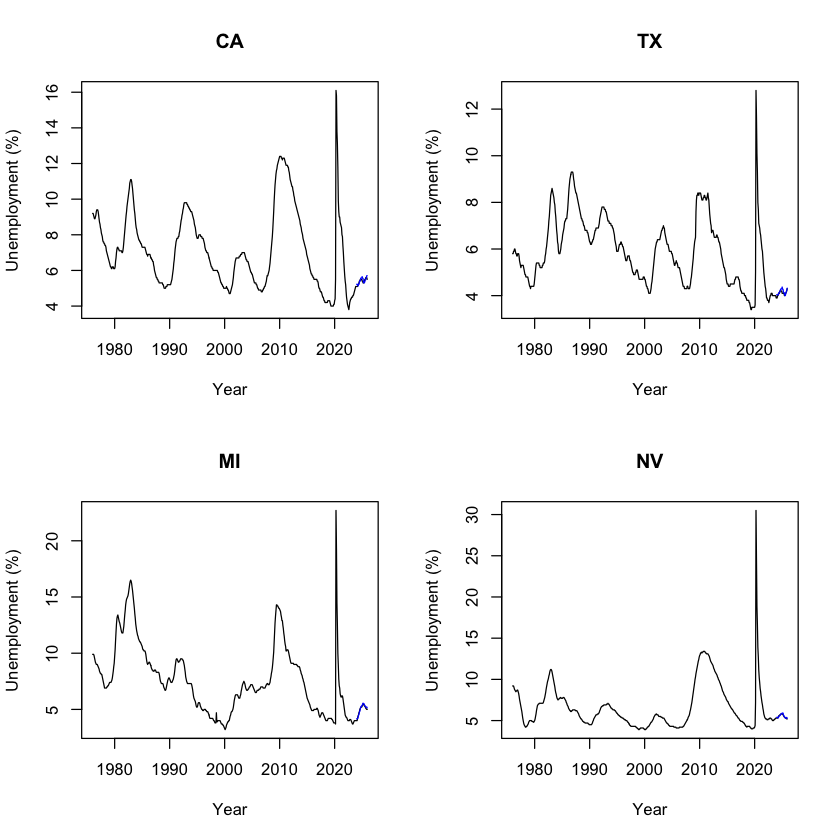

In [32]:
plot_states <- c("CA", "TX", "MI", "NV")

par(mfrow = c(2, 2))

for (s in plot_states) {
  obs  <- bls %>% filter(state == s) %>% arrange(date)
  pred <- forecasts2 %>% filter(state == s) %>% arrange(date)

  plot(obs$date, obs$unemployment_rate, type = "l",
       main = s, xlab = "Year", ylab = "Unemployment (%)")
  lines(pred$date, pred$y_pred, col = "blue")
}

par(mfrow = c(1, 1))

## 11. VI comparison

In [ ]:
fit2_vi <- mod2$variational(
  data      = stan_data,
  seed      = 405,
  algorithm = "meanfield",
  draws     = 1000
)

params <- c("mu_beta", "sigma_beta", "gamma_fed", "gamma_gdp")

hmc_sum <- fit2$summary(params) %>%
  select(variable, mean, q5, q95) %>%
  mutate(method = "HMC")

vi_sum <- fit2_vi$summary(params) %>%
  select(variable, mean, q5, q95) %>%
  mutate(method = "VI")

bind_rows(hmc_sum, vi_sum) %>%
  ggplot(aes(x = variable, y = mean, colour = method)) +
  geom_point(position = position_dodge(0.4)) +
  geom_errorbar(aes(ymin = q5, ymax = q95), width = 0.2, position = position_dodge(0.4)) +
  labs(title = "Model 2: HMC vs VI", x = NULL, y = "Posterior mean") +
  theme_minimal()

------------------------------------------------------------ 
EXPERIMENTAL ALGORITHM: 
  This procedure has not been thoroughly tested and may be unstable 
  or buggy. The interface is subject to change. 
------------------------------------------------------------ 
Gradient evaluation took 0.004815 seconds 
1000 transitions using 10 leapfrog steps per transition would take 48.15 seconds. 
Adjust your expectations accordingly! 
Begin eta adaptation. 
Iteration:   1 / 250 [  0%]  (Adaptation) 
Iteration:  50 / 250 [ 20%]  (Adaptation) 
Iteration: 100 / 250 [ 40%]  (Adaptation) 
Iteration: 150 / 250 [ 60%]  (Adaptation) 
Success! Found best value [eta = 10] earlier than expected. 
Begin stochastic gradient ascent. 
  iter             ELBO   delta_ELBO_mean   delta_ELBO_med   notes  


Chain 1 stan::variational::normal_meanfield::calc_grad: The number of dropped evaluations has reached its maximum amount (10). Your model may be either severely ill-conditioned or misspecified.

Warning message:
"Fitting finished unexpectedly! Use the $output() method for more information.
"


Finished in  1.4 seconds.


ERROR: Error: Fitting failed. Unable to retrieve the draws.


------------------------------------------------------------ 
EXPERIMENTAL ALGORITHM: 
  This procedure has not been thoroughly tested and may be unstable 
  or buggy. The interface is subject to change. 
------------------------------------------------------------ 
Gradient evaluation took 0.004638 seconds 
1000 transitions using 10 leapfrog steps per transition would take 46.38 seconds. 
Adjust your expectations accordingly! 
Begin eta adaptation. 
Iteration:   1 / 250 [  0%]  (Adaptation) 
Iteration:  50 / 250 [ 20%]  (Adaptation) 
Iteration: 100 / 250 [ 40%]  (Adaptation) 
Iteration: 150 / 250 [ 60%]  (Adaptation) 
Iteration: 200 / 250 [ 80%]  (Adaptation) 
Iteration: 250 / 250 [100%]  (Adaptation) 
Success! Found best value [eta = 0.1]. 
Begin stochastic gradient ascent. 
  iter             ELBO   delta_ELBO_mean   delta_ELBO_med   notes  
   100   -699873295.564             1.000            1.000 
   200  -2023559660.390             0.827            1.000 
   300   -339092522.244

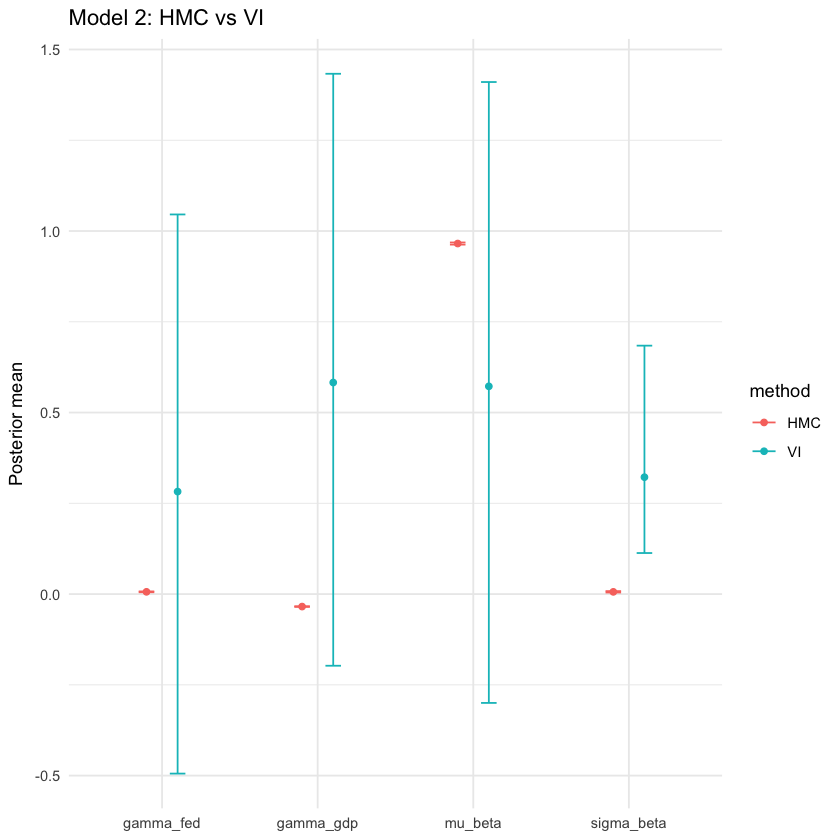

In [ ]:
fit2_vi <- mod2$variational(
  data      = stan_data,
  seed      = 405,
  algorithm = "fullrank",
  draws     = 1000
)

params <- c("mu_beta", "sigma_beta", "gamma_fed", "gamma_gdp")

hmc_sum <- fit2$summary(params) %>%
  select(variable, mean, q5, q95) %>%
  mutate(method = "HMC")

vi_sum <- fit2_vi$summary(params) %>%
  select(variable, mean, q5, q95) %>%
  mutate(method = "VI")

bind_rows(hmc_sum, vi_sum) %>%
  ggplot(aes(x = variable, y = mean, colour = method)) +
  geom_point(position = position_dodge(0.4)) +
  geom_errorbar(aes(ymin = q5, ymax = q95), width = 0.2, position = position_dodge(0.4)) +
  labs(title = "Model 2: HMC vs VI", x = NULL, y = "Posterior mean") +
  theme_minimal()

# Sensitivity Testing

In [35]:
mod2_wide  <- cmdstan_model("model2_wide.stan")
mod2_tight <- cmdstan_model("model2_tight.stan")

fit2_wide  <- mod2_wide$sample(data = stan_data, seed = 405, chains = 4,
                                parallel_chains = 4, iter_warmup = 500,
                                iter_sampling = 500, refresh = 250)

fit2_tight <- mod2_tight$sample(data = stan_data, seed = 405, chains = 4,
                                 parallel_chains = 4, iter_warmup = 500,
                                 iter_sampling = 500, refresh = 250)

cat("Base  sigma_beta:", fit2$summary("sigma_beta")$mean, "\n")
cat("Wide  sigma_beta:", fit2_wide$summary("sigma_beta")$mean, "\n")
cat("Tight sigma_beta:", fit2_tight$summary("sigma_beta")$mean, "\n")

Running MCMC with 4 parallel chains...

Chain 1 Iteration:   1 / 1000 [  0%]  (Warmup) 
Chain 2 Iteration:   1 / 1000 [  0%]  (Warmup) 
Chain 3 Iteration:   1 / 1000 [  0%]  (Warmup) 
Chain 4 Iteration:   1 / 1000 [  0%]  (Warmup) 
Chain 4 Iteration: 250 / 1000 [ 25%]  (Warmup) 
Chain 3 Iteration: 250 / 1000 [ 25%]  (Warmup) 
Chain 1 Iteration: 250 / 1000 [ 25%]  (Warmup) 
Chain 2 Iteration: 250 / 1000 [ 25%]  (Warmup) 
Chain 3 Iteration: 500 / 1000 [ 50%]  (Warmup) 
Chain 3 Iteration: 501 / 1000 [ 50%]  (Sampling) 
Chain 4 Iteration: 500 / 1000 [ 50%]  (Warmup) 
Chain 4 Iteration: 501 / 1000 [ 50%]  (Sampling) 
Chain 1 Iteration: 500 / 1000 [ 50%]  (Warmup) 
Chain 1 Iteration: 501 / 1000 [ 50%]  (Sampling) 
Chain 2 Iteration: 500 / 1000 [ 50%]  (Warmup) 
Chain 2 Iteration: 501 / 1000 [ 50%]  (Sampling) 
Chain 3 Iteration: 750 / 1000 [ 75%]  (Sampling) 
Chain 4 Iteration: 750 / 1000 [ 75%]  (Sampling) 
Chain 1 Iteration: 750 / 1000 [ 75%]  (Sampling) 
Chain 3 Iteration: 1000 / 1000 [10

In [ ]:
# Base: mu_beta ~ N(0.5, 0.3)
# Alternative: mu_beta ~ N(0.9, 0.3)

mod2_mubeta <- cmdstan_model("model2_betaa.stan")

fit2_mubeta <- mod2_mubeta$sample(
  data            = stan_data,
  seed            = 405,
  chains          = 4,
  parallel_chains = 4,
  iter_warmup     = 500,
  iter_sampling   = 500,
  refresh         = 250
)

params <- c("mu_beta", "sigma_beta", "gamma_fed", "gamma_gdp")

base_sum <- fit2$summary(params) %>%
  select(variable, mean, q5, q95) %>%
  mutate(prior = "Base: mu_beta ~ N(0.5, 0.3)")

sens_sum <- fit2_mubeta$summary(params) %>%
  select(variable, mean, q5, q95) %>%
  mutate(prior = "Sens: mu_beta ~ N(0.9, 0.3)")

bind_rows(base_sum, sens_sum) %>%
  arrange(variable, prior) %>%
  print()

Running MCMC with 4 parallel chains...

Chain 4 Iteration:   1 / 1000 [  0%]  (Warmup) 
Chain 1 Iteration:   1 / 1000 [  0%]  (Warmup) 
Chain 2 Iteration:   1 / 1000 [  0%]  (Warmup) 
Chain 3 Iteration:   1 / 1000 [  0%]  (Warmup) 
Chain 4 Iteration: 250 / 1000 [ 25%]  (Warmup) 
Chain 1 Iteration: 250 / 1000 [ 25%]  (Warmup) 
Chain 2 Iteration: 250 / 1000 [ 25%]  (Warmup) 
Chain 3 Iteration: 250 / 1000 [ 25%]  (Warmup) 
Chain 4 Iteration: 500 / 1000 [ 50%]  (Warmup) 
Chain 4 Iteration: 501 / 1000 [ 50%]  (Sampling) 
Chain 1 Iteration: 500 / 1000 [ 50%]  (Warmup) 
Chain 1 Iteration: 501 / 1000 [ 50%]  (Sampling) 
Chain 2 Iteration: 500 / 1000 [ 50%]  (Warmup) 
Chain 2 Iteration: 501 / 1000 [ 50%]  (Sampling) 
Chain 3 Iteration: 500 / 1000 [ 50%]  (Warmup) 
Chain 3 Iteration: 501 / 1000 [ 50%]  (Sampling) 
Chain 4 Iteration: 750 / 1000 [ 75%]  (Sampling) 
Chain 1 Iteration: 750 / 1000 [ 75%]  (Sampling) 
Chain 2 Iteration: 750 / 1000 [ 75%]  (Sampling) 
Chain 3 Iteration: 750 / 1000 [ 75